In [1]:
pip install pandas numpy matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np

In [10]:
from google.colab import files
uploaded = files.upload()

Saving inventory_demand_stockout_risk.csv to inventory_demand_stockout_risk.csv


In [12]:
df = pd.read_csv("inventory_demand_stockout_risk.csv")

In [17]:
df.info

<bound method DataFrame.info of      product_id        date store_id  current_stock  daily_demand  \
0         P1000  2024-01-01       S7            213           114   
1         P1001  2024-01-02      S20            152            87   
2         P1002  2024-01-03      S15            209            62   
3         P1003  2024-01-04      S11            400           103   
4         P1004  2024-01-05       S8             60           114   
...         ...         ...      ...            ...           ...   
2795      P3795  2031-08-27       S9            464            11   
2796      P3796  2031-08-28       S1            104            48   
2797      P3797  2031-08-29       S8            227            72   
2798      P3798  2031-08-30       S6            246            38   
2799      P3799  2031-08-31       S6            187            70   

      lead_time_days  supplier_reliability_score promotion_active  \
0                  5                          72               No   
1                  7                          84               No   
2                 10                          61               No   
3                 10                          61               No   
4                  9                          75               No   
...              ...                         ...              ...   
2795              10                          86              Yes   
2796              10                          83              Yes   
2797               9                          78               No   
2798               4                          67              Yes   
2799               7                          61               No   

     weather_impact stockout_risk  
0            Medium            No  
1              High           Yes  
2               Low            No  
3               Low            No  
4            Medium            No  
...             ...           ...  
2795            Low           Yes  
2796         Medium           Yes  
2797         Medium            No  
2798           High           Yes  
2799            Low            No  

[2800 rows x 10 columns]>

In [14]:
df.shape

(2800, 10)

The dataset contains 2800 rows and 10 columns

In [15]:
df.columns

Index(['product_id', 'date', 'store_id', 'current_stock', 'daily_demand',
       'lead_time_days', 'supplier_reliability_score', 'promotion_active',
       'weather_impact', 'stockout_risk'],
      dtype='object')

Column	                Meaning
product_id-	            unique product identifier
store_id-	              store identifier
current_stock-	          current inventory level
daily_demand-	          expected demand per day
lead_time_days-	        supplier delivery time
supplier_reliability_score-	supplier performance indicator
promotion_active-	      promotion running or not
weather_impact-       	weather affecting demand
stockout_risk-          target variable

In [18]:
df.describe()

,current_stock,daily_demand,lead_time_days,supplier_reliability_score
count,2800.000000,2800.000000,2800.000000,2800.000000
mean,250.288214,61.925714,7.432143,79.252857
std,143.466643,32.981750,4.006029,11.235899
min,0.000000,5.000000,1.000000,60.000000
25%,125.000000,33.000000,4.000000,70.000000
50%,249.000000,62.000000,7.000000,79.000000
75%,376.250000,90.000000,11.000000,89.000000
max,499.000000,119.000000,14.000000,99.000000


Average daily demand is 62
Average current stock is 251
significant variation in demand as well as in stock.

In [19]:
df.isnull().sum()

,0
product_id,0
date,0
store_id,0
current_stock,0
daily_demand,0
lead_time_days,0
supplier_reliability_score,0
promotion_active,0
weather_impact,0
stockout_risk,0


No missing value in the dataset.

In [20]:
df["stockout_risk"].value_counts()

,count
stockout_risk,
No,2110
Yes,690


In [21]:
df["stockout_risk"].value_counts(normalize=True) * 100

,proportion
stockout_risk,
No,75.357143
Yes,24.642857


Out of 2800 observations, stock out risk is in 690 i.e. 24.64%.

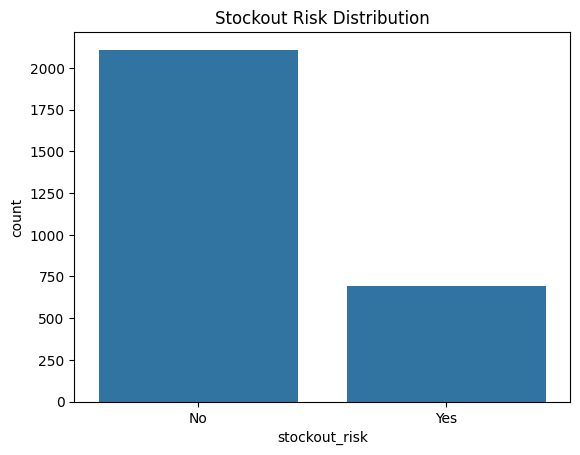

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="stockout_risk", data=df)
plt.title("Stockout Risk Distribution")
plt.show()

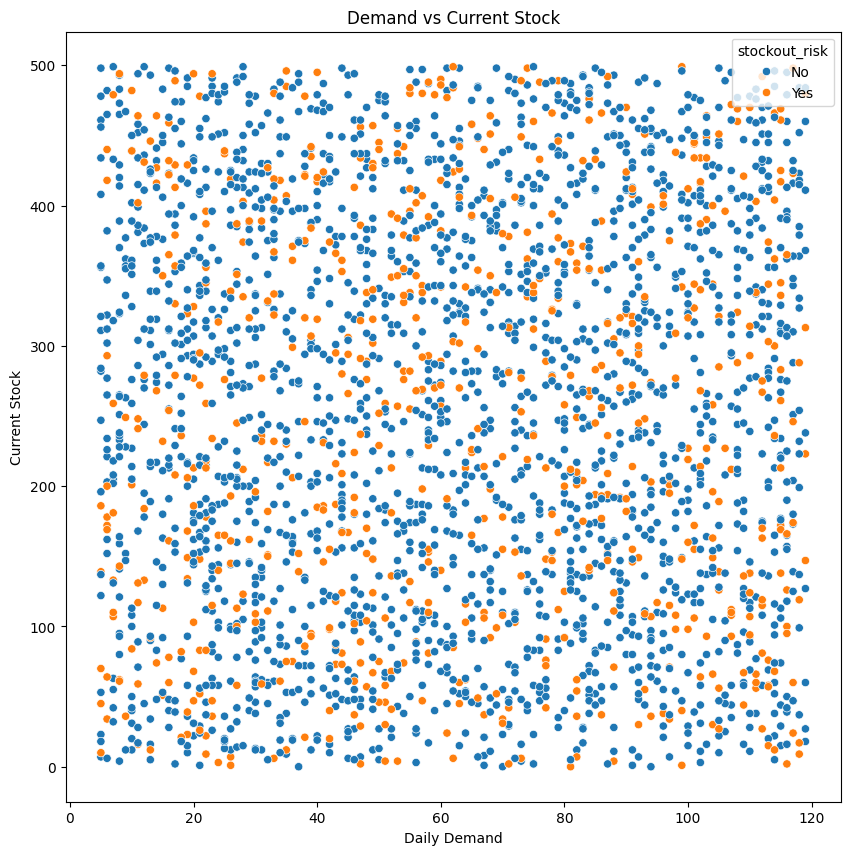

In [28]:
plt.figure(figsize=(10,10))

sns.scatterplot(x="daily_demand", y="current_stock", hue="stockout_risk", data=df)

plt.title("Demand vs Current Stock")
plt.xlabel("Daily Demand")
plt.ylabel("Current Stock")

plt.show()

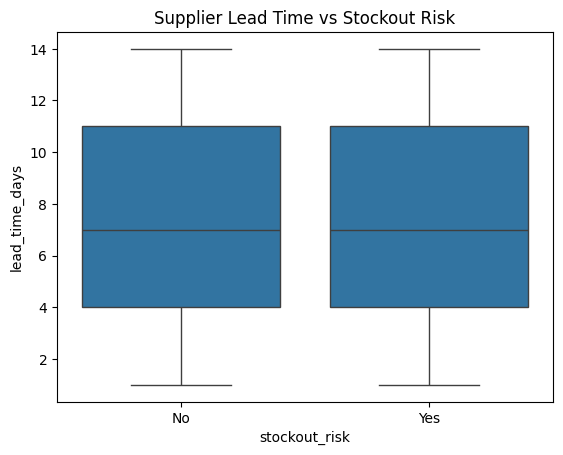

In [29]:
sns.boxplot(x="stockout_risk", y="lead_time_days", data=df)

plt.title("Supplier Lead Time vs Stockout Risk")

plt.show()

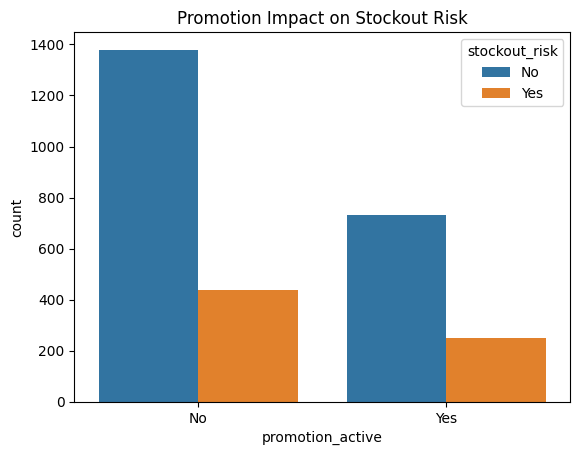

In [30]:
sns.countplot(x="promotion_active", hue="stockout_risk", data=df)

plt.title("Promotion Impact on Stockout Risk")

plt.show()

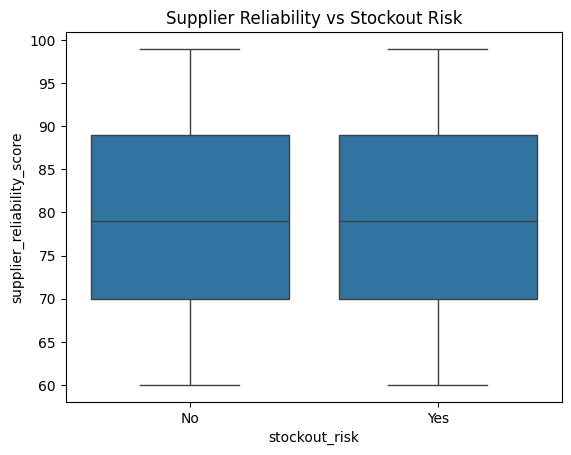

In [31]:
sns.boxplot(x="stockout_risk", y="supplier_reliability_score", data=df)

plt.title("Supplier Reliability vs Stockout Risk")

plt.show()